# Fase 1: Análise Exploratória (EDA)

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

In [196]:
pd.read_csv('./manutencao_preditiva.csv')

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


In [197]:
df = pd.read_csv('./manutencao_preditiva.csv', sep=',')


In [198]:
df.head(60)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741.0,28.0,21,0,0,0,0,0,0


# Imagem 01: Visualização das primeiras linhas do Dataframe bruto

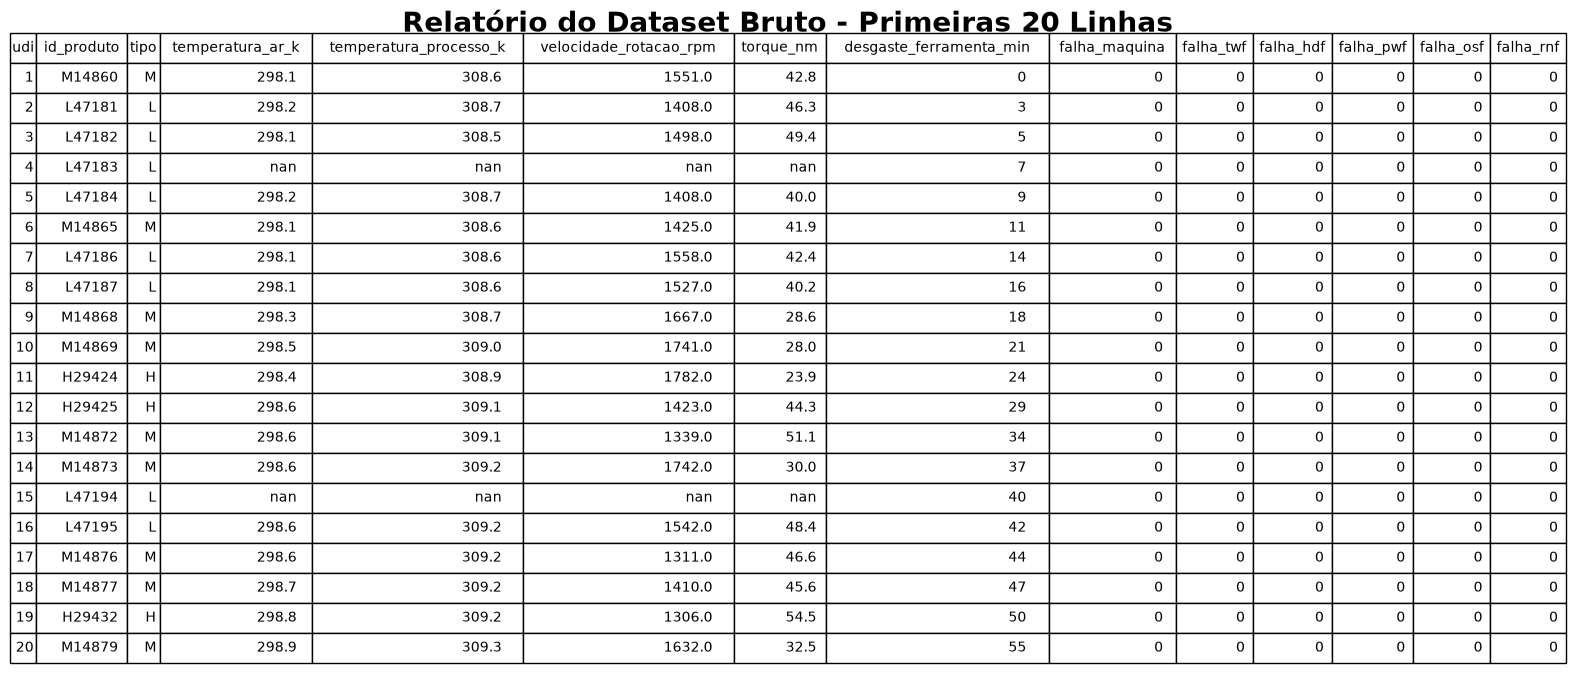

In [199]:
# Pegar as primeiras linhas do dataset
tabela = df.head(20)

# Criar figura
fig, ax = plt.subplots(figsize=(18, 8))

plt.title(
    "Relatório do Dataset Bruto - Primeiras 20 Linhas",
    fontsize=20,
    fontweight="bold"
)

# Remover eixos
ax.axis("off")

# Criar tabela
table = ax.table(
    cellText=tabela.values,
    colLabels=tabela.columns,
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(10)


# Ajusta a largura das colunas dinamicamente com base no conteúdo das células
table.auto_set_column_width(col=list(range(len(tabela.columns))))

# Dá um espaçamento maior entre as linhas e colunas da tabela
table.scale(1.2, 1.8)

# Salvar imagem
plt.savefig(
    "imagens/01_dataset_bruto_head.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [200]:
print('***Informações do DataFrame***')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')

***Informações do DataFrame***
Número de linhas: 10000
Número de colunas: 14


In [201]:
print('\n***Informações sobre os tipos de dados das variáveis***')
df.dtypes


***Informações sobre os tipos de dados das variáveis***


udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

In [202]:
print('***Resumo estatístico das colunas numéricas***')
df.describe()

***Resumo estatístico das colunas numéricas***


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [203]:
print(df.columns.tolist())

['udi', 'id_produto', 'tipo', 'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']


In [204]:
print(df.isnull().sum())

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64


# Gráfico 02: Histograma de Distribuiçao das Variáveis Preditoras

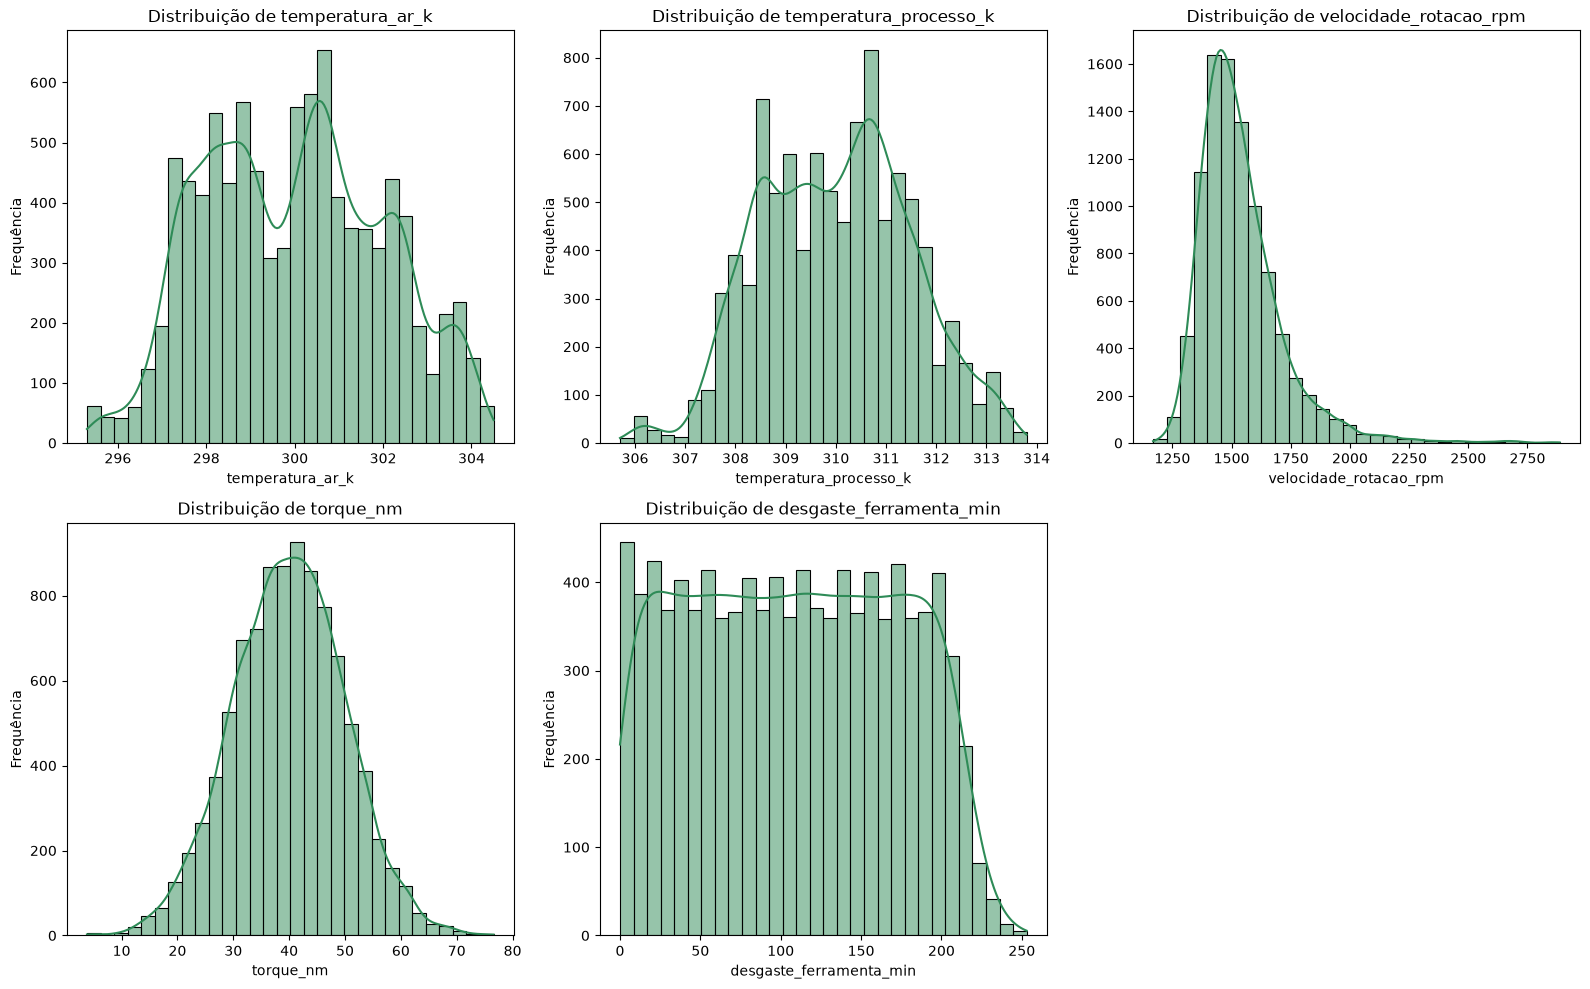

In [205]:
colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=coluna, kde=True, color='seagreen', bins=30)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/02_distribuicao_sensores.png', dpi=300, bbox_inches='tight')
plt.show()

O histograma apresenta a distribuição das principais variáveis monitoradas pelos sensores da máquina. Observa-se a frequência com que determinados valores de temperatura, velocidade de rotação, torque e desgaste da ferramenta ocorrem na base de dados. Essa análise permite identificar a concentração dos valores, possíveis assimetrias, dispersões e indícios de valores extremos, fornecendo uma visão inicial da qualidade dos dados e do comportamento das variáveis que serão utilizadas para prever falhas mecânicas. Essas informações auxiliam na escolha das técnicas de pré-processamento e na construção de modelos de classificação mais adequados.

# Gráfico 03: Countplot das Variáveis alvo

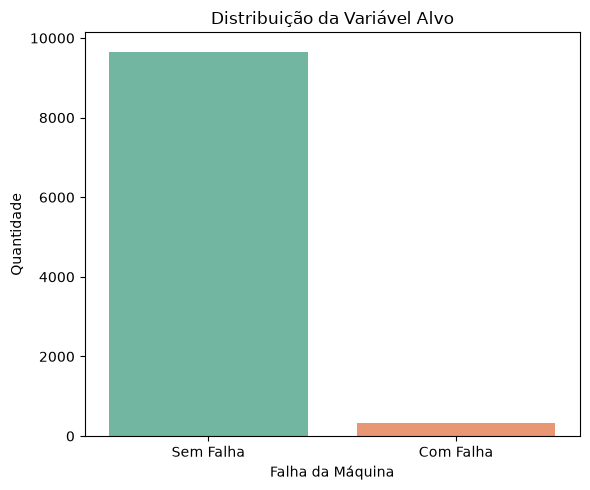

In [206]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='falha_maquina',
    hue='falha_maquina',
    palette='Set2',
    legend=False
)

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Falha da Máquina')
plt.ylabel('Quantidade')

plt.xticks(
    [0,1],
    ['Sem Falha','Com Falha']
)

plt.tight_layout()
plt.savefig("imagens/03_balanceamento.png", dpi=300)
plt.show()


In [207]:
(df['falha_maquina']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))

falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64

96,61% dos registros representam máquinas em funcionamento normal (falha_maquina = 0).
3,39% dos registros representam máquinas que apresentaram falha (falha_maquina = 1).

# Gráfico 04: Heatmap Mapa de calor da correlação

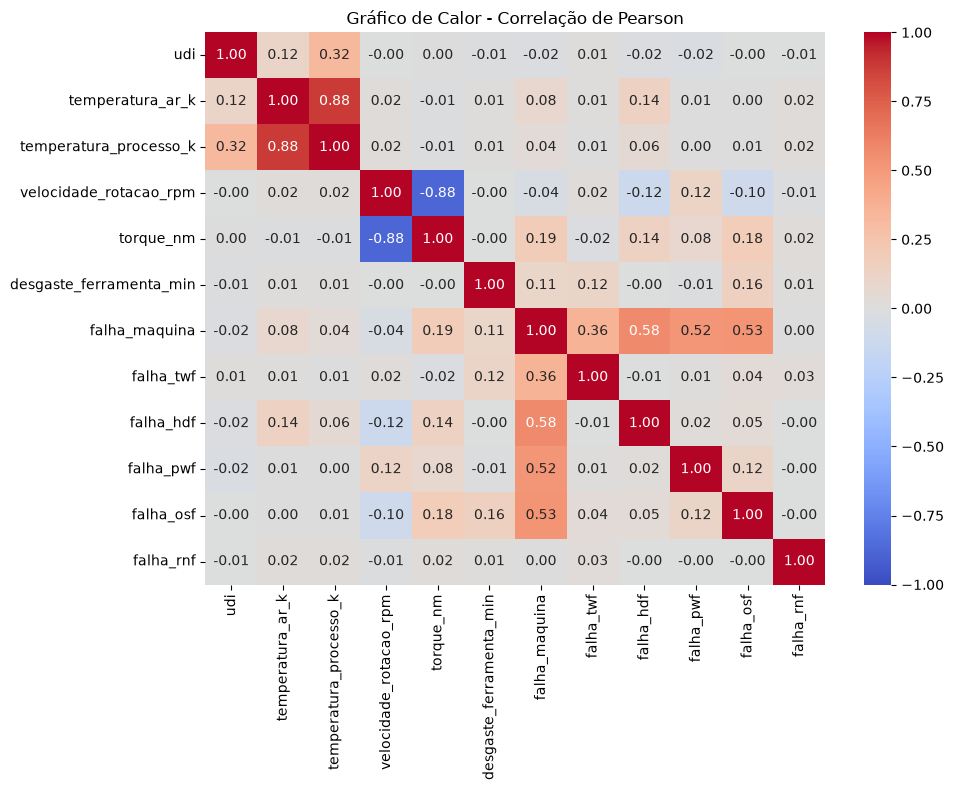

In [208]:
# Calcula a matriz de correlação de Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)
# Desenha o gráfico de calor 
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, 
vmax=1) 
plt.title('Gráfico de Calor - Correlação de Pearson') 
plt.tight_layout()
plt.savefig("imagens/04_heatmap.png", dpi=300)
plt.show()

### Análise Estratégica do Mapa de Calor (Correlação de Pearson)

O gráfico de correlação acima serve como base técnica e justifica as decisões tomadas nas próximas etapas do projeto:

1. Justificativa para a Fase 3 (Feature Engineering):
   Identificamos uma correlação negativa extremamente forte (*-0.88*) entre velocidade_rotacao_rpm e torque_nm. Na mecânica, isso indica que quando a velocidade aumenta, o torque diminui. Essa forte relação justifica a criação da variável combinada potencia, ajudando o modelo a capturar essa interação de forma direta.

2. Justificativa para a Fase 4 (Prevenção de Data Leakage): 
   A nossa variável alvo (falha_maquina) apresenta alta correlação com as colunas específicas de motivos de falha, como falha_hdf (0.58), falha_osf (0.53) e falha_pwf (0.52). Isso prova que manter essas variáveis no conjunto de treino causaria vazamento de dados (Data Leakage), obrigando a remoção delas no passo de divisão dos dados.

3. Justificativa para a Fase 5 (Escalonamento de Variáveis):
   Existem variáveis fortemente correlacionadas que operam em grandezas numéricas totalmente diferentes (ex: temperaturas na casa das centenas, velocidade na casa dos milhares e torque na casa das dezenas). Para que o modelo não priorize uma variável apenas pelo tamanho do seu número, torna-se obrigatório o ajuste de escala (StandardScaler).

🔴 Vermelho → correlação positiva.
🔵 Azul → correlação negativa.
⚪ Próximo do branco → correlação próxima de zero.

# Fase 2: Limpeza e Tratamento de Dados (Data Prep) e Cria Uma cópia independente na memória

In [209]:
df_limpo = df.copy()

In [210]:
df_limpo

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


# Verificação e Limpeza dos dados ausentes e duplicados

In [211]:
# Conta quantos dados ausentes existem em cada coluna
df_limpo.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [212]:
# Mostra apenas as linhas que possuem qualquer valor ausente
df_limpo[df_limpo.isnull().any(axis=1)]

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
14,15,L47194,L,NaN,NaN,NaN,NaN,40,0,0,0,0,0,0
29,30,L47209,L,NaN,NaN,NaN,NaN,84,0,0,0,0,0,0
31,32,L47211,L,NaN,NaN,NaN,NaN,89,0,0,0,0,0,0
33,34,L47213,L,NaN,NaN,NaN,NaN,93,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9783,9784,H39197,H,NaN,NaN,NaN,NaN,66,0,0,0,0,0,0
9896,9897,M24756,M,NaN,NaN,NaN,NaN,173,0,0,0,0,0,0
9909,9910,L57089,L,NaN,NaN,NaN,NaN,2,0,0,0,0,0,0
9920,9921,H39334,H,NaN,NaN,NaN,NaN,28,0,0,0,0,0,0


In [213]:
# Conta o total de linhas 100% duplicadas no DataFrame
total_duplicadas = df_limpo.duplicated().sum()
print(f'Total de linhas duplicadas: {total_duplicadas}')

Total de linhas duplicadas: 0


In [214]:
# Exibe as linhas duplicadas no DataFrame
linhas_duplicadas = df_limpo[df_limpo.duplicated(keep=False)]
print(f'Linhas duplicadas:\n{linhas_duplicadas}')

Linhas duplicadas:
Empty DataFrame
Columns: [udi, id_produto, tipo, temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm, torque_nm, desgaste_ferramenta_min, falha_maquina, falha_twf, falha_hdf, falha_pwf, falha_osf, falha_rnf]
Index: []


# Uso da Média e da Mediana para preenchimento dos dados ausentes

# Gráfico 05: Com Outlier

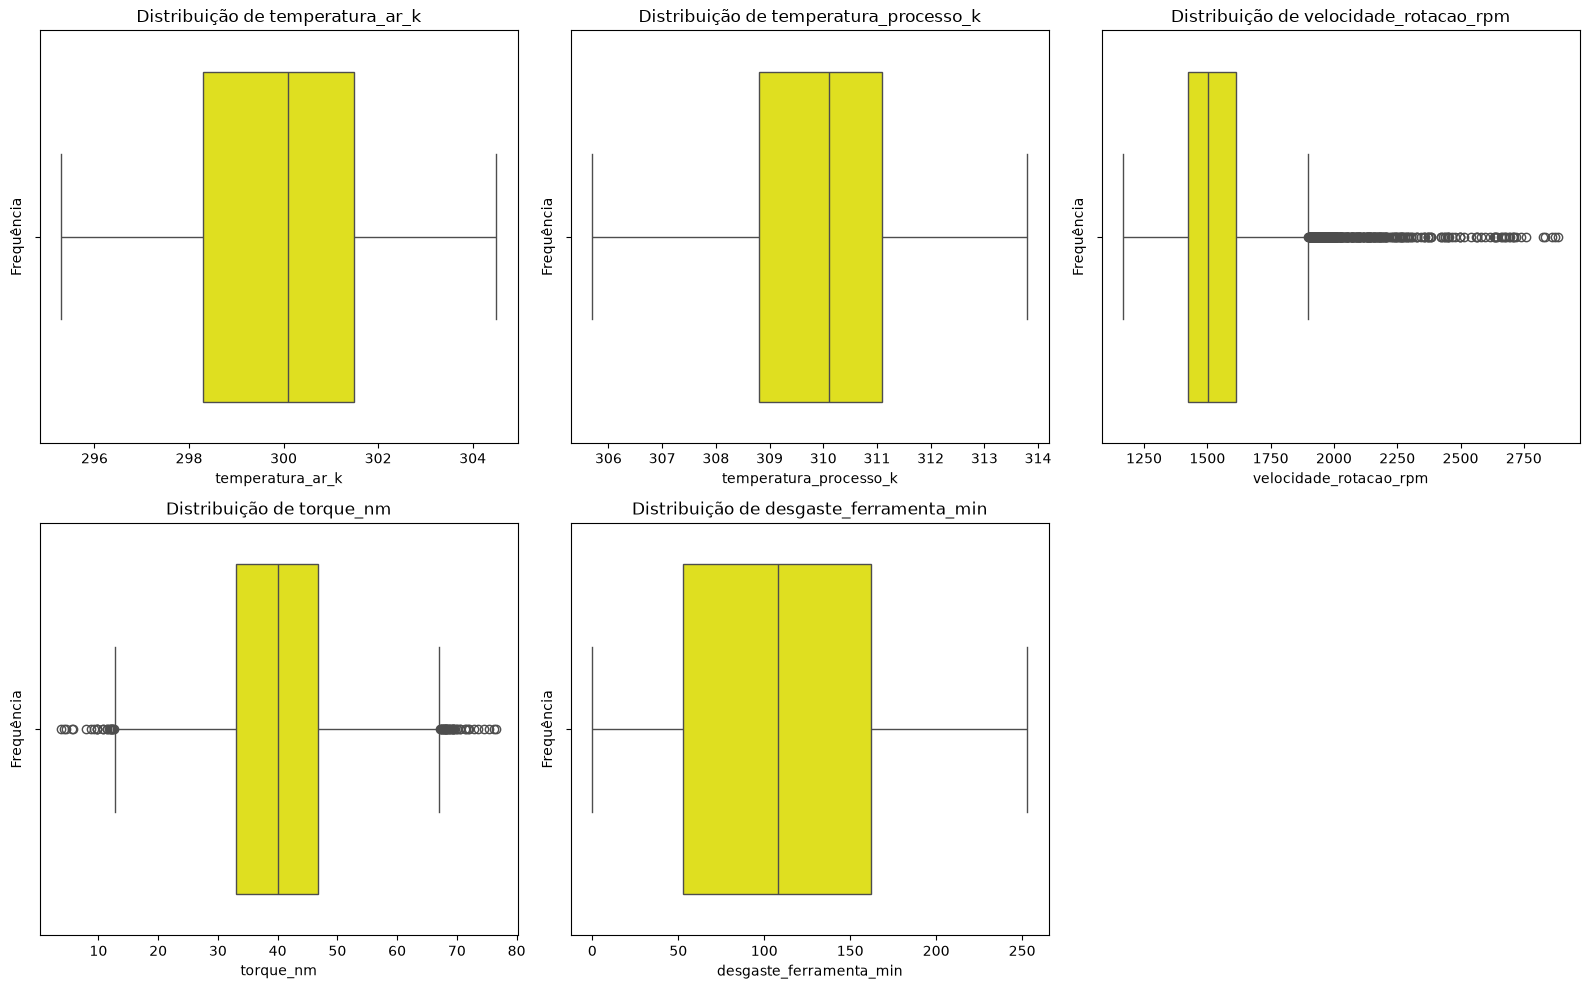

In [215]:
outlier_colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=coluna, color='yellow', showfliers=True)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/05_boxplot_sensores_com_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

# A escolha da mediana se deu pela presença clara de outliers nas extremidades dessas distribuicões, pois sofre menos influência sobre os valores extremos, preservando a tendência central dos dados.

In [216]:
mediana_rotacao = df_limpo['velocidade_rotacao_rpm'].median()
df_limpo['velocidade_rotacao_rpm'] = df_limpo['velocidade_rotacao_rpm'].fillna(mediana_rotacao)

In [217]:
mediana_torque = df_limpo['torque_nm'].median()
df_limpo['torque_nm'] = df_limpo['torque_nm'].fillna(mediana_torque)

# A escolha da média se deu pela distribuições simétricas e comportadas, sem a ocorrência de nenhum outlier. Nesse cenário a média representa perfeitamente o centro dos dados

In [218]:
media_temp = df_limpo['temperatura_ar_k'].mean()
df_limpo['temperatura_ar_k'] = df_limpo['temperatura_ar_k'].fillna(media_temp)

In [219]:
media_processo = df_limpo['temperatura_processo_k'].mean()
df_limpo['temperatura_processo_k'] = df_limpo['temperatura_processo_k'].fillna(media_processo)

In [220]:
# Mostra o df_limpo atualizado após o tratamento de valores ausentes
df_limpo.isnull().sum()

udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

In [221]:
# Mostra o df_limpo atualizado após o tratamento de valores ausentes
df_limpo[df_limpo.isnull().any(axis=1)]

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf


In [222]:
df_limpo.head(60)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.100000,308.600000,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.200000,308.700000,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.100000,308.500000,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,300.002158,310.000895,1504.0,40.1,7,0,0,0,0,0,0
4,5,L47184,L,298.200000,308.700000,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.100000,308.600000,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.100000,308.600000,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.100000,308.600000,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.300000,308.700000,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.500000,309.000000,1741.0,28.0,21,0,0,0,0,0,0


# Imagem 06: Visualização primeiras linhas do Dataframe limpo

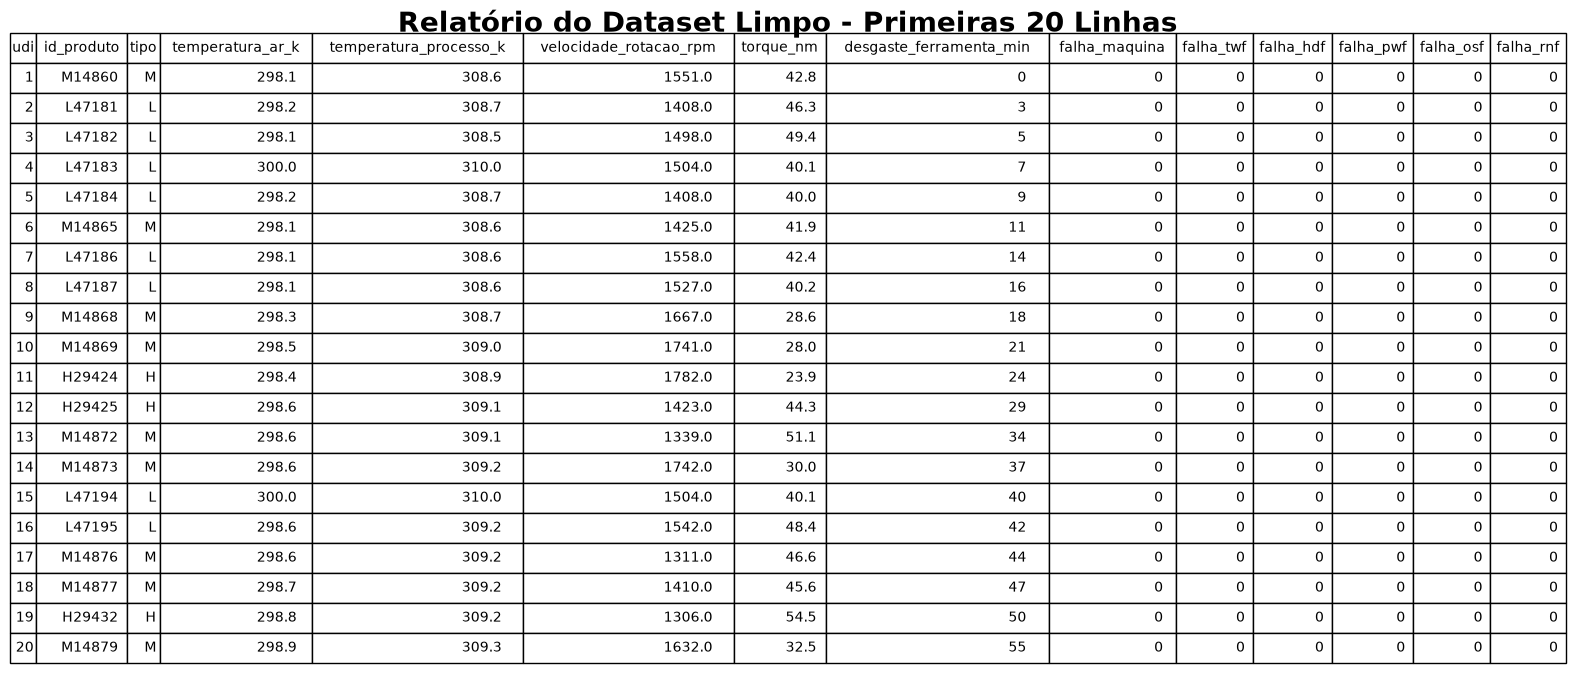

In [223]:
# Pegar as primeiras linhas do dataset
tabela = df_limpo.head(20)

# Criar figura
fig, ax = plt.subplots(figsize=(18, 8))

plt.title(
    "Relatório do Dataset Limpo - Primeiras 20 Linhas",
    fontsize=20,
    fontweight="bold"
)

# Remover eixos
ax.axis("off")

# Formatar os valores da tabela para exibir apenas uma casa decimal
tabela_formatada = tabela.round(1)

# Criar tabela
table = ax.table(
    cellText=tabela_formatada.values,
    colLabels=tabela_formatada.columns,
    loc="center"
)

# Ajustar tamanho
table.auto_set_font_size(False)
table.set_fontsize(10)

# Ajusta a largura das colunas dinamicamente com base no conteúdo das células
table.auto_set_column_width(col=list(range(len(tabela.columns))))

# Dá um espaçamento maior entre as linhas e colunas da tabela
table.scale(1.2, 1.8)

# Salvar imagem
plt.savefig(
    "imagens/06_dataset_limpo_head.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Gráfico 07: Sem Outlier

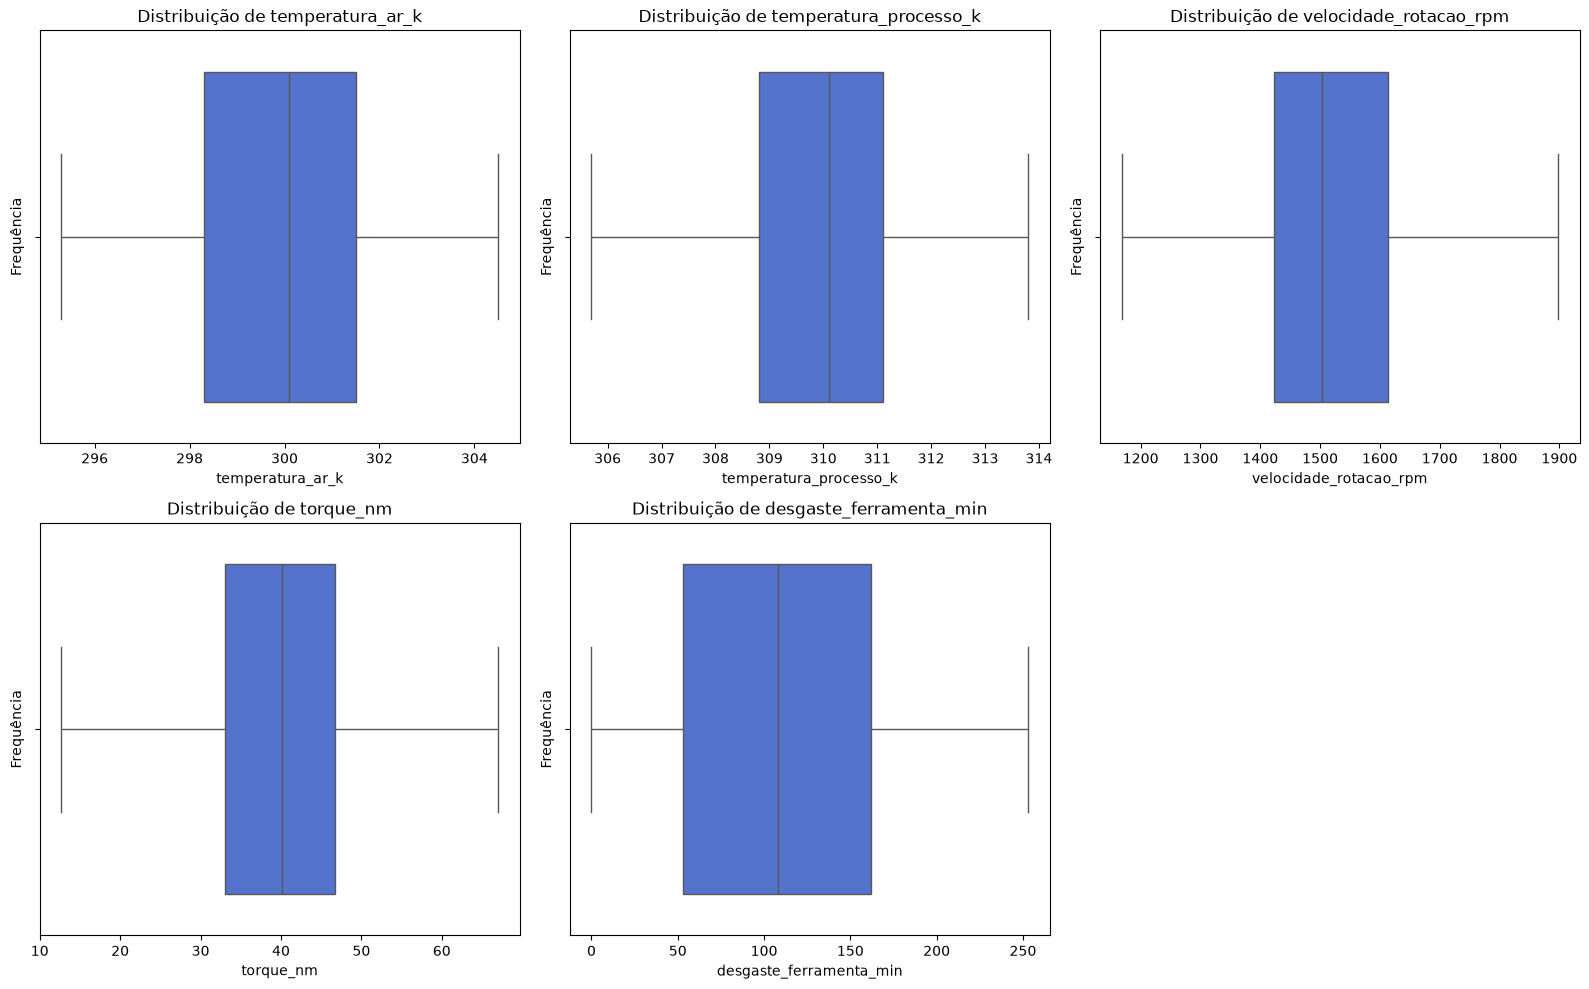

In [224]:
outlier_colunas_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm',
    'desgaste_ferramenta_min'
]

plt.figure(figsize=(16, 10))

for i, coluna in enumerate(colunas_sensores, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=coluna, color='royalblue', showfliers=False)
    plt.title(f'Distribuição de {coluna}', fontsize=12)
    plt.xlabel(coluna, fontsize=10)
    plt.ylabel('Frequência', fontsize=10)

plt.tight_layout()
plt.savefig('imagens/07_boxplot_sensores_sem_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

Fase 3: Feature Engineering

In [225]:
df_limpo['potencia'] = df_limpo['velocidade_rotacao_rpm'] * df_limpo['torque_nm']

df_limpo[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head(5)

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


Fase 4: Divisão e Balanceamento dos Dados

### Balanceamento das Classes com SMOTE

O balanceamento foi realizado porque a base de dados possui poucos exemplos de falha em comparação com a classe sem falha, caracterizando um desbalanceamento entre as classes.

Foi utilizado o algoritmo **SMOTE (Synthetic Minority Over-sampling Technique)**, que gera exemplos sintéticos da classe minoritária para equilibrar a quantidade de amostras.

O SMOTE foi aplicado **apenas ao conjunto de treinamento**, preservando o conjunto de teste com sua distribuição original. Dessa forma, a avaliação do modelo é realizada em dados mais próximos da realidade, evitando vieses nos resultados.

In [226]:
# Colunas que não serão utilizadas como variáveis preditoras
features_to_drop = [
    'udi',
    'id_produto',
    'falha_maquina',
    'falha_twf',
    'falha_hdf',
    'falha_pwf',
    'falha_osf',
    'falha_rnf'
]

# Variáveis independentes (X) e variável alvo (y)
X = df_limpo.drop(columns=features_to_drop)
y = df_limpo['falha_maquina']

# Converter variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

# Dividir em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Aplicar o SMOTE apenas no conjunto de treinamento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Exibir informações dos conjuntos
print("Treino após SMOTE:", X_train_smote.shape, y_train_smote.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino após SMOTE: (15458, 8) (15458,)
Teste: (2000, 8) (2000,)


In [227]:
print("Antes do SMOTE")
print(y.value_counts())

print("\nDepois do SMOTE")
print(y_train.value_counts())

Antes do SMOTE
falha_maquina
0    9661
1     339
Name: count, dtype: int64

Depois do SMOTE
falha_maquina
0    7729
1     271
Name: count, dtype: int64


# Imagem 08: Visualização antes e depois do SMOTE

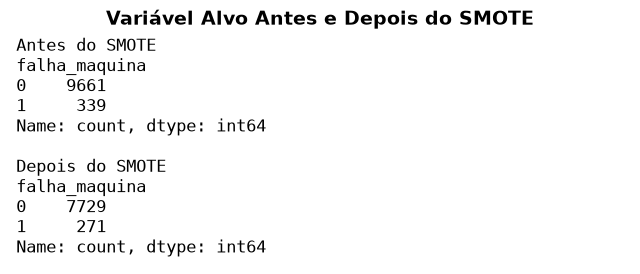

In [228]:
texto = (
    "Antes do SMOTE\n"
    f"{y.value_counts()}\n\n"
    "Depois do SMOTE\n"
    f"{y_train.value_counts()}"
)

fig = plt.figure(figsize=(8, 3))

plt.title(
    "Variável Alvo Antes e Depois do SMOTE",
    fontsize=14,
    fontweight="bold"
)



plt.text(
    0.01,
    0.05,
    texto,
    fontsize=12,
    family="monospace"
)

plt.axis("off")

plt.savefig(
    "imagens/08_smote_balanceamento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Fase 5: Escalonamento de Variáveis (StandardScaler)

Nesta etapa, ajustamos a escala de todas as variáveis numéricas do conjunto de dados:

1. Padronização: Como temos variáveis em escalas totalmente diferentes (ex: velocidade na casa dos milhares e torque na casa das dezenas), usamos o StandardScaler para que todas fiquem na mesma ordem de grandeza (média 0 e desvio padrão 1).
2. Prevenção de Data Leakage: O ajuste (fit_transform) foi aplicado apenas nos dados de treino. Os dados de teste foram apenas transformados (transform), garantindo que o modelo não conheça a média ou o desvio padrão dos dados de teste antes da avaliação.


In [229]:
# Escalonamento para Modelo KNN
scaler = StandardScaler()

# Ajustar e transformar APENAS os dados de treino balanceados
X_train_scaled = scaler.fit_transform(X_train_smote)

# Transformar os dados de teste usando o mesmo aprendizado do treino
X_test_scaled = scaler.transform(X_test)

print("Conjunto de treinamento escalonado:")
print(X_train_scaled[:5])  

Conjunto de treinamento escalonado:
[[-0.22359929 -0.11945315 -0.05538453 -0.32347494 -1.04813138 -0.27769582
  -1.73519387  1.42742143]
 [-1.82014027 -1.42875958 -0.41381923  0.12160935  0.1275212   0.03335318
  -1.73519387  1.42742143]
 [ 0.30705095  1.11149828 -0.55719311  0.06509071  0.20288355 -0.17168833
  -1.73519387  1.42742143]
 [-0.80972444 -0.27409691 -0.37285527  0.82102753 -0.59595731  1.01488872
   0.57630448 -0.70056395]
 [-1.76696049 -1.27480455  0.72634447 -1.12886558 -1.10842126 -0.99215844
   0.57630448 -0.70056395]]


Fase 6: Ajuste de Parâmetros e Combate ao Overfitting

Modelo KNN

## Análise do KNN (Overfitting e escalabilidade)

Identificação de Overfitting: Ocorre um leve sinal em k=3. Nessa configuração, o modelo alcançou a maior acurácia de treino (97,10%), mas a distância para acurácia de teste (91,35%) é a maior entre os testes (uma difrença de 5,75%). Isso mostra que o k=3 ficou um pouco mais ajustado aos dados do treino.

Configuração mais estável: A configuração mais estável para a acurácia geral é k=5 e k=7, onde a diferença de treino e teste diminue (mais ou menos 5,2%). No entanto, olhando o equilibrio das métricas, k=5 entrega o melhor f1-Score (32,09%) e um bom Recall (63,24%), sem perder muita acurácia.

In [230]:
Knn_results = []
for k in (3,5,7):
    # Criação do modelo KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Treinamento do modelo
    knn.fit(X_train_scaled, y_train_smote)
    
    # Previsão no conjunto de teste
    y_pred = knn.predict(X_test_scaled)
    y_pred_train = knn.predict(X_train_scaled)
    
    # Avaliação do modelo
    accuracy_treino = accuracy_score(y_train_smote, y_pred_train)
    accuracy_teste = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Armazenar os resultados
    Knn_results.append({
        'k': k,
        'accuracy_treino': accuracy_treino,
        'accuracy_teste': accuracy_teste,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })
    print(f"Resultados para k={k}:")
    print(f"Accuracy treino: {accuracy_treino:.4f}")
    print(f"Accuracy teste: {accuracy_teste:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

Resultados para k=3:
Accuracy treino: 0.9710
Accuracy teste: 0.9135
Precision: 0.2162
Recall: 0.5882
F1-Score: 0.3162

Resultados para k=5:
Accuracy treino: 0.9608
Accuracy teste: 0.9090
Precision: 0.2150
Recall: 0.6324
F1-Score: 0.3209

Resultados para k=7:
Accuracy treino: 0.9544
Accuracy teste: 0.9015
Precision: 0.2028
Recall: 0.6471
F1-Score: 0.3088



Imagem 09: Visualização do Modelo KNN

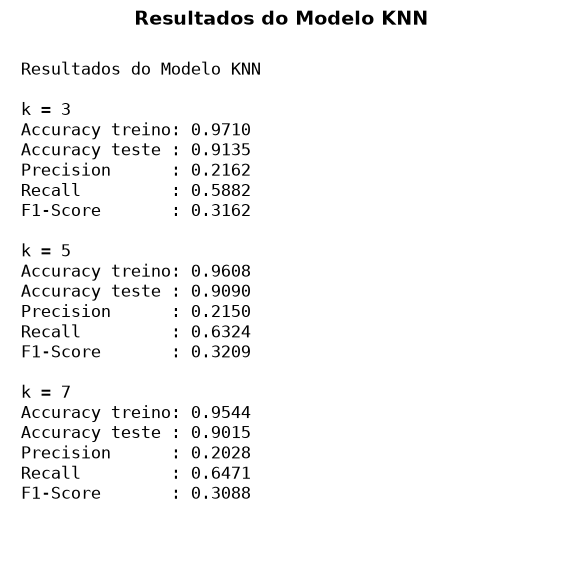

In [231]:
# Criar texto com os resultados do KNN

texto = "Resultados do Modelo KNN\n\n"

for resultado in Knn_results:
    texto += (
        f"k = {resultado['k']}\n"
        f"Accuracy treino: {resultado['accuracy_treino']:.4f}\n"
        f"Accuracy teste : {resultado['accuracy_teste']:.4f}\n"
        f"Precision      : {resultado['precision']:.4f}\n"
        f"Recall         : {resultado['recall']:.4f}\n"
        f"F1-Score       : {resultado['f1_score']:.4f}\n\n"
    )

# Criar figura
fig = plt.figure(figsize=(7, 7))

plt.title(
    "Resultados do Modelo KNN",
    fontsize=14,
    fontweight="bold"
)

plt.text(
    0.02,
    0.95,
    texto,
    fontsize=12,
    family="monospace",
    va="top"
)

plt.axis("off")

plt.savefig(
    "imagens/09_resultados_knn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Modelo Arvore de Decisão

Ocorrência de Overfitting: O Overfitting ocorreu de forma explícita na configuração max_depth=None (profundidade ilimitda). O modelo memorizou os dados de treinamento, atingindo uma acurácia de treino extremamente elevada (99,45%), com isso o modelo deixa falhas generalizadas em modelos reais fora do conjunto controlado.

Configuração de Estabilidade: A configuração que garantiu a melhor estabilidade e o melhor equilbrio para o modelo foi max_depth=5. Nessa profundidade, a acurácia de treino e teste mantiveram muito próximas e equilibradas, provando alta capacidade de generalização. Além disso, essa configuração apresentou uma evolução sólida no F1-Score (36,69%) e no Recall (75,00%) se comparando á profundidade de corte igual a 3.



In [238]:
# Lista para armazenar os resultados
tree_results = []

# Criar e treinar o modelo Decision Tree
profundidades = [3, 5, None]  # Adicione None para permitir profundidade ilimitada

for depth in profundidades:
    # Criação do modelo Decision Tree
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Treinamento do modelo
    dt.fit(X_train_scaled, y_train_smote)
    
    # Previsão no conjunto de teste
    y_pred = dt.predict(X_test_scaled)
    y_pred_train = dt.predict(X_train_scaled)
    
    # Avaliação do modelo
    accuracy_treino = accuracy_score(y_train_smote, y_pred_train)
    accuracy_teste = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Armazenar os resultados
    print(f"Resultados para profundidade={depth}:")
    print(f"Accuracy treino: {accuracy_treino:.4f}")
    print(f"Accuracy teste: {accuracy_teste:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")# Calcular as métricas finais


Resultados para profundidade=3:
Accuracy treino: 0.8579
Accuracy teste: 0.8595
Precision: 0.1365
Recall: 0.5882
F1-Score: 0.2216

Resultados para profundidade=5:
Accuracy treino: 0.9034
Accuracy teste: 0.9120
Precision: 0.2429
Recall: 0.7500
F1-Score: 0.3669

Resultados para profundidade=None:
Accuracy treino: 0.9945
Accuracy teste: 0.9435
Precision: 0.3427
Recall: 0.7206
F1-Score: 0.4645



In [244]:
# Lista para armazenar os resultados
tree_results = []

# Profundidades testadas
profundidades = [3, 5, None]

for depth in profundidades:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    dt.fit(X_train_scaled, y_train_smote)

    y_pred = dt.predict(X_test_scaled)
    y_pred_train = dt.predict(X_train_scaled)

    accuracy_treino = accuracy_score(y_train_smote, y_pred_train)
    accuracy_teste = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tree_results.append({
        "profundidade": depth,
        "accuracy_treino": accuracy_treino,
        "accuracy_teste": accuracy_teste,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    print(f"Resultados para profundidade={depth}")
    print(f"Accuracy treino: {accuracy_treino:.4f}")
    print(f"Accuracy teste : {accuracy_teste:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-Score       : {f1:.4f}\n")

Resultados para profundidade=3
Accuracy treino: 0.8579
Accuracy teste : 0.8595
Precision      : 0.1365
Recall         : 0.5882
F1-Score       : 0.2216

Resultados para profundidade=5
Accuracy treino: 0.9034
Accuracy teste : 0.9120
Precision      : 0.2429
Recall         : 0.7500
F1-Score       : 0.3669

Resultados para profundidade=None
Accuracy treino: 0.9945
Accuracy teste : 0.9435
Precision      : 0.3427
Recall         : 0.7206
F1-Score       : 0.4645



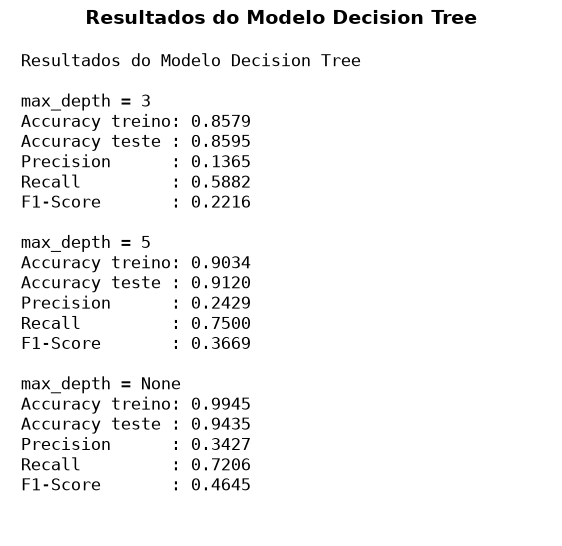

In [247]:
# Criar texto com os resultados da Decision Tree
texto = "Resultados do Modelo Decision Tree\n\n"

for resultado in tree_results:

    texto += (
        f"max_depth = {resultado['profundidade']}\n"
        f"Accuracy treino: {resultado['accuracy_treino']:.4f}\n"
        f"Accuracy teste : {resultado['accuracy_teste']:.4f}\n"
        f"Precision      : {resultado['precision']:.4f}\n"
        f"Recall         : {resultado['recall']:.4f}\n"
        f"F1-Score       : {resultado['f1_score']:.4f}\n\n"
    )

# Criar figura
fig = plt.figure(figsize=(7, 5))

plt.title(
    "Resultados do Modelo Decision Tree",
    fontsize=14,
    fontweight="bold"
)

plt.text(
    0.02,
    0.95,
    texto,
    fontsize=12,
    family="monospace",
    va="top"
)

plt.axis("off")

plt.savefig(
    "imagens/10_resultados_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Fase 7: Avaliação da Acurácia e Veredito Final

### Fase 7: Veredito Final e Recomendação de Negócio

Após a execução dos testes com dados inéditos (conjunto de teste isolado), os modelos apresentaram desempenhos consistentes após o tratamento de desbalanceamento via SMOTE e normalização dos dados.

#### Conclusão Técnica
O modelo que apresentou maior estabilidade e capacidade de generalização foi a *Árvore de Decisão (com max_depth=5)*. Enquanto o KNN demonstrou boa acurácia global, a Árvore de Decisão com profundidade controlada evitou o overfitting de forma mais eficiente, mantendo métricas de teste (Acurácia, Recall e F1-Score) superiores e mais equilibradas em relação ao treino.

#### Recomendação para a Empresa
Recomendamos a implementação da *Árvore de Decisão* no pipeline de produção da empresa. Esta escolha baseia-se em dois pilares práticos:
1. *Poder de Generalização:* Menor discrepância entre dados de treino e teste, reduzindo falsos positivos no diagnóstico de falhas mecânicas.
2. *Explicabilidade:* Árvores de decisão geram regras claras de corte de dados (ex: temperatura > X, rotação < Y), permitindo que a equipe de engenharia de manutenção entenda o motivo de o modelo disparar um alerta de falha de máquina, algo inviável com a lógica de vizinhos matemáticos do KNN.

In [233]:
# Instaciar os melhores hiperparâmetros para os modelos KNN e Decision Tree
melhor_knn = KNeighborsClassifier(n_neighbors=5)
melhor_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treinar os modelos com os dados balenceados (SMOTE) e escalonados
melhor_knn.fit(X_train_scaled, y_train_smote)
melhor_tree.fit(X_train_scaled, y_train_smote)

# Gerar previsões nos dados de teste escalonados
y_pred_knn_final = melhor_knn.predict(X_test_scaled)
y_pred_tree_final = melhor_tree.predict(X_test_scaled)

# Exibir resultados de forma comparativa
print("=== Comparativo Final de Acurácia (Dados de Teste) ===")
print(f"Acurácia Final do KNN (k=5): {accuracy_score(y_test, y_pred_knn_final):.4f}")
print(f"Acurácia Final do Decision Tree (max_depth=5): {accuracy_score(y_test, y_pred_tree_final):.4f}")

=== Comparativo Final de Acurácia (Dados de Teste) ===
Acurácia Final do KNN (k=5): 0.9090
Acurácia Final do Decision Tree (max_depth=5): 0.9120


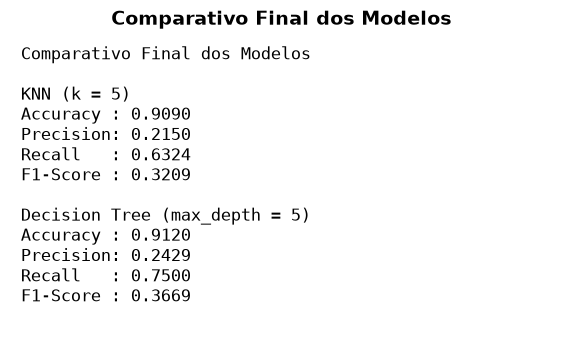

In [242]:
# Calcular as métricas finais
acc_knn = accuracy_score(y_test, y_pred_knn_final)
prec_knn = precision_score(y_test, y_pred_knn_final)
rec_knn = recall_score(y_test, y_pred_knn_final)
f1_knn = f1_score(y_test, y_pred_knn_final)

acc_tree = accuracy_score(y_test, y_pred_tree_final)
prec_tree = precision_score(y_test, y_pred_tree_final)
rec_tree = recall_score(y_test, y_pred_tree_final)
f1_tree = f1_score(y_test, y_pred_tree_final)

# Criar texto com os resultados
texto = (
    "Comparativo Final dos Modelos\n\n"

    "KNN (k = 5)\n"
    f"Accuracy : {acc_knn:.4f}\n"
    f"Precision: {prec_knn:.4f}\n"
    f"Recall   : {rec_knn:.4f}\n"
    f"F1-Score : {f1_knn:.4f}\n\n"

    "Decision Tree (max_depth = 5)\n"
    f"Accuracy : {acc_tree:.4f}\n"
    f"Precision: {prec_tree:.4f}\n"
    f"Recall   : {rec_tree:.4f}\n"
    f"F1-Score : {f1_tree:.4f}\n"
)

# Criar figura
fig = plt.figure(figsize=(7, 3))

plt.title(
    "Comparativo Final dos Modelos",
    fontsize=14,
    fontweight="bold"
)

plt.text(
    0.02,
    0.95,
    texto,
    fontsize=12,
    family="monospace",
    va="top"
)

plt.axis("off")

plt.savefig(
    "imagens/11_comparativo_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()